# Analisi risultati regressione

Statistiche descrittive (media, deviazione standard) e boxplot per modello su ciascun foglio di `new_results/results_regression.xlsx`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

In [ ]:
BASE_DIR = Path(".").resolve()
RESULTS_PATH = BASE_DIR / "results" / "run_v5.3" / "results_regression.xlsx"
FIGURES_DIR = BASE_DIR / "results"  / "run_v5.3" / "figures_regression"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

METRICS = ["MAE", "MSE", "RMSE", "R2", "MAPE", "MEDAE", "EVS"]
MODEL_ORDER = ["XGBoost", "LightGBM", "DT", "SVR"]

assert RESULTS_PATH.exists(), f"File non trovato: {RESULTS_PATH}"

In [3]:
sheets = pd.read_excel(RESULTS_PATH, sheet_name=None)
print("Fogli disponibili:", list(sheets.keys()))
for name, df in sheets.items():
    print(f"  {name}: {df.shape[0]} righe, modelli = {df['Model'].unique().tolist()}")

Fogli disponibili: ['sis', 'oks', 'ohs']
  sis: 90 righe, modelli = ['XGBoost', 'CatBoost', 'LightGBM', 'DecisionTreeRegressor (DT)', 'SVR']
  oks: 90 righe, modelli = ['XGBoost', 'CatBoost', 'LightGBM', 'DecisionTreeRegressor (DT)', 'SVR']
  ohs: 90 righe, modelli = ['XGBoost', 'CatBoost', 'LightGBM', 'DecisionTreeRegressor (DT)', 'SVR']


## Media e deviazione standard per modello

In [4]:
def summary_by_model(df: pd.DataFrame) -> pd.DataFrame:
    """Media e std per ogni metrica, raggruppate per Model."""
    stats = df.groupby("Model", observed=True)[METRICS].agg(["mean", "std"])
    stats = stats.reindex(MODEL_ORDER)
    stats.columns = [f"{metric}_{stat}" for metric, stat in stats.columns]
    return stats.round(4)


summary_tables = {}
for sheet_name, df in sheets.items():
    summary_tables[sheet_name] = summary_by_model(df)
    print(f"\n=== {sheet_name.upper()} ===")
    display(summary_tables[sheet_name])


=== SIS ===


,MAE_mean,MAE_std,MSE_mean,MSE_std,RMSE_mean,RMSE_std,R2_mean,R2_std,MAPE_mean,MAPE_std,MEDAE_mean,MEDAE_std,EVS_mean,EVS_std
Model,,,,,,,,,,,,,,
XGBoost,2.4149,1.1718,8.5032,6.6032,2.6641,1.2199,-10.5881,22.5182,0.1086,0.0618,2.3180,1.2262,0.2230,0.3961
LightGBM,2.3775,1.1601,8.1513,6.4741,2.6111,1.1883,-10.4060,22.3989,0.1068,0.0608,2.2704,1.1807,0.2563,0.4266
DT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SVR,3.4740,1.6043,17.9386,14.4622,3.9175,1.6565,-17.9833,34.2167,0.1582,0.0886,3.4216,1.7445,-1.8874,3.0598



=== OKS ===


,MAE_mean,MAE_std,MSE_mean,MSE_std,RMSE_mean,RMSE_std,R2_mean,R2_std,MAPE_mean,MAPE_std,MEDAE_mean,MEDAE_std,EVS_mean,EVS_std
Model,,,,,,,,,,,,,,
XGBoost,5.8517,3.8912,52.9193,53.0663,6.2975,3.7471,-8.9499,13.9442,0.2145,0.1513,5.6999,4.1091,0.3173,0.3595
LightGBM,5.7406,3.7553,50.2518,48.4934,6.1505,3.6269,-8.3188,13.3014,0.2123,0.1518,5.6031,3.9888,0.3256,0.3617
DT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SVR,8.2055,5.4817,103.1120,115.2712,8.7695,5.2677,-16.7379,23.7566,0.2862,0.1698,8.1506,5.7875,-0.1211,0.1959



=== OHS ===


,MAE_mean,MAE_std,MSE_mean,MSE_std,RMSE_mean,RMSE_std,R2_mean,R2_std,MAPE_mean,MAPE_std,MEDAE_mean,MEDAE_std,EVS_mean,EVS_std
Model,,,,,,,,,,,,,,
XGBoost,4.8809,3.1704,38.4178,43.7888,5.3704,3.1843,-9.2639,17.3436,0.1876,0.1205,4.6184,3.2754,0.1559,0.3060
LightGBM,4.8836,3.1069,37.8158,42.9852,5.3468,3.1258,-9.2316,17.1197,0.1874,0.1168,4.6743,3.2256,0.1979,0.2192
DT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SVR,6.2495,4.7695,67.6827,86.2914,6.8095,4.7504,-16.5904,31.6577,0.2327,0.1606,6.1391,4.8967,-0.1580,0.3779


## Boxplot: confronto modelli (per foglio)

Ogni figura mostra tutte le metriche per un singolo outcome (foglio). I modelli sono sull'asse x; ogni box riassume la distribuzione su pazienti e fold CV.

Salvato: C:\Users\Alessio\HOME\Git Projects (local)\MAISON-ML\results\run_v5.2\figures_regression\boxplot_models_sis.png


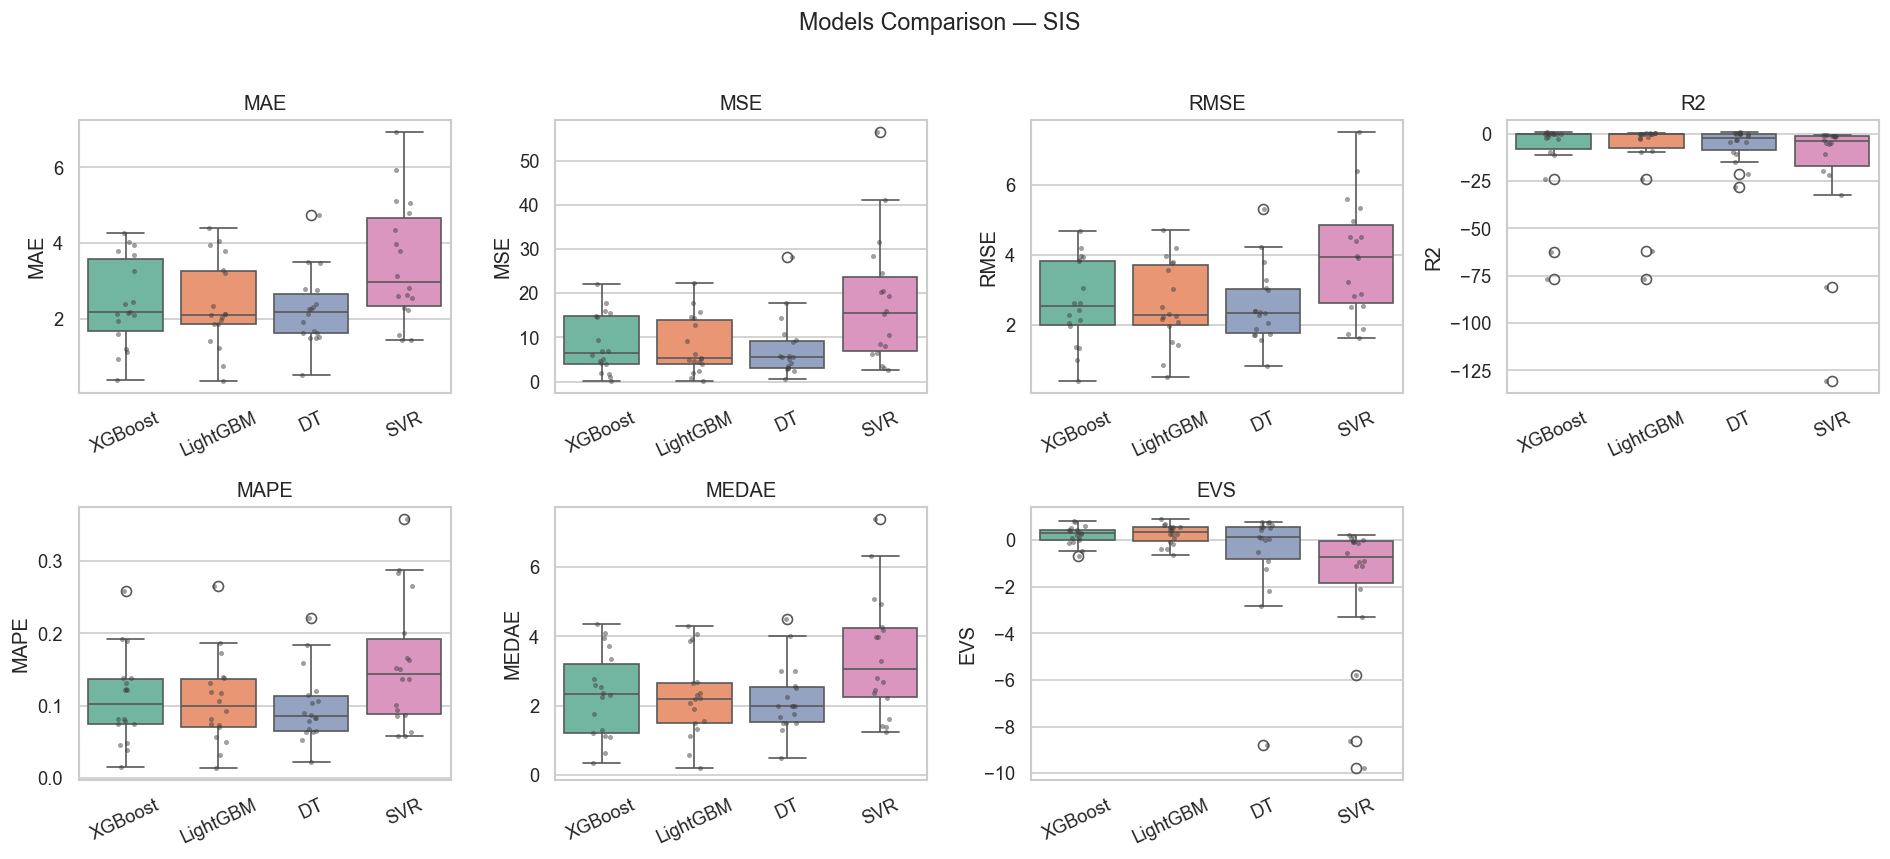

Salvato: C:\Users\Alessio\HOME\Git Projects (local)\MAISON-ML\results\run_v5.2\figures_regression\boxplot_models_oks.png


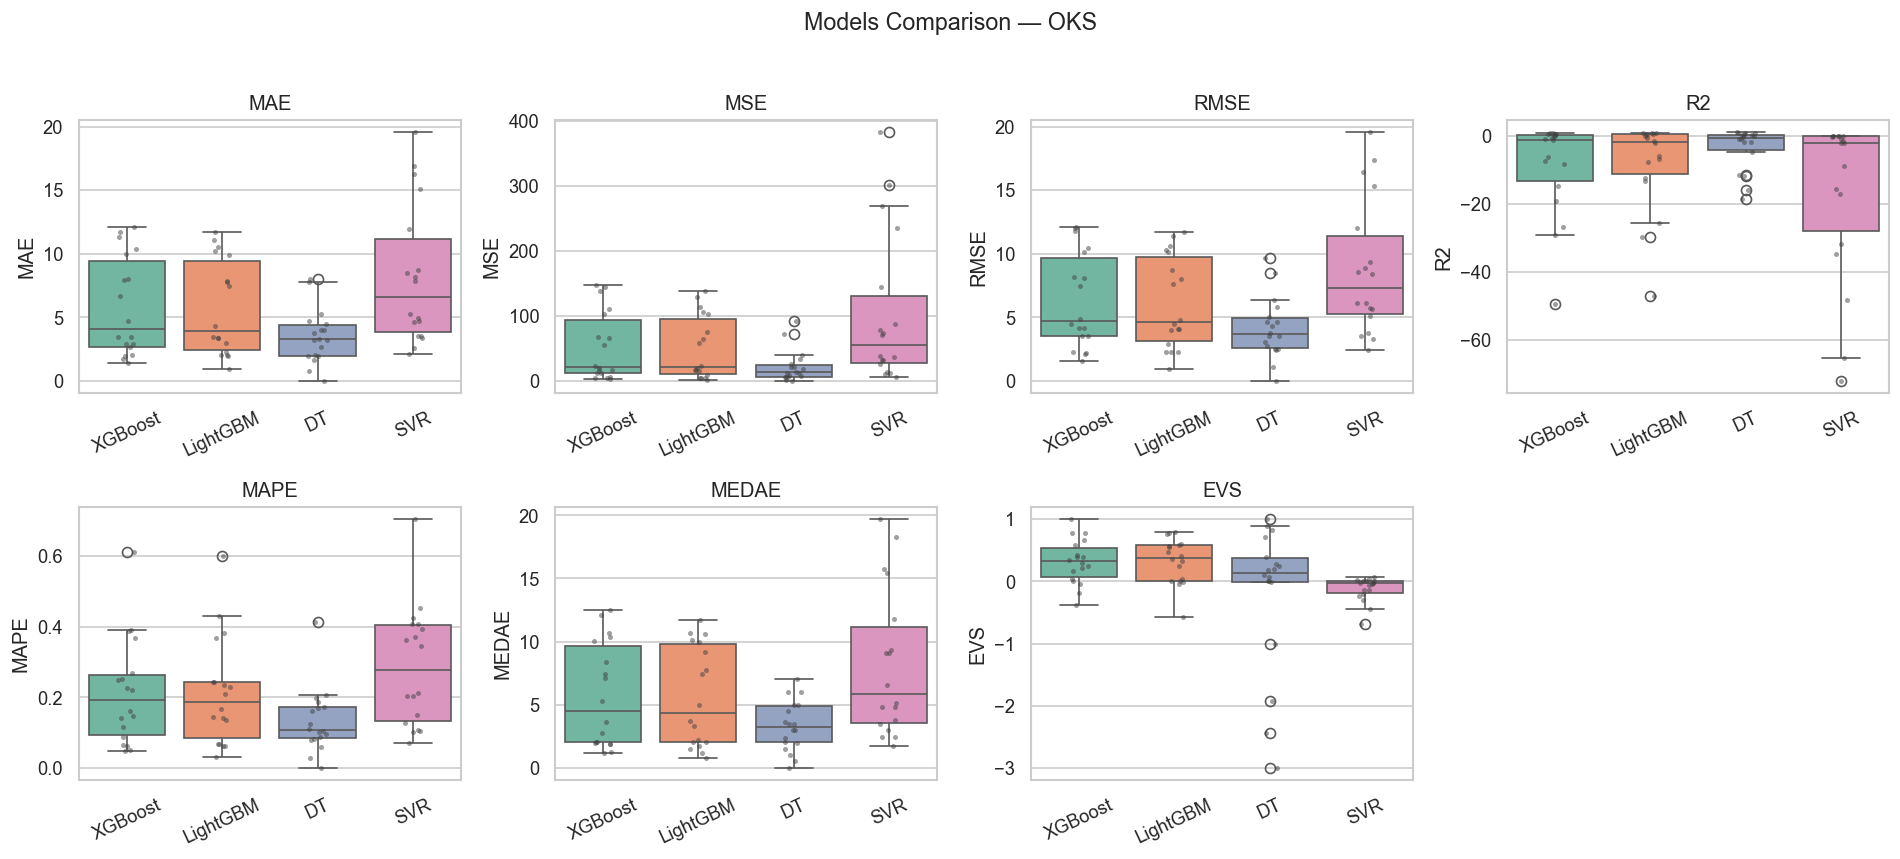

Salvato: C:\Users\Alessio\HOME\Git Projects (local)\MAISON-ML\results\run_v5.2\figures_regression\boxplot_models_ohs.png


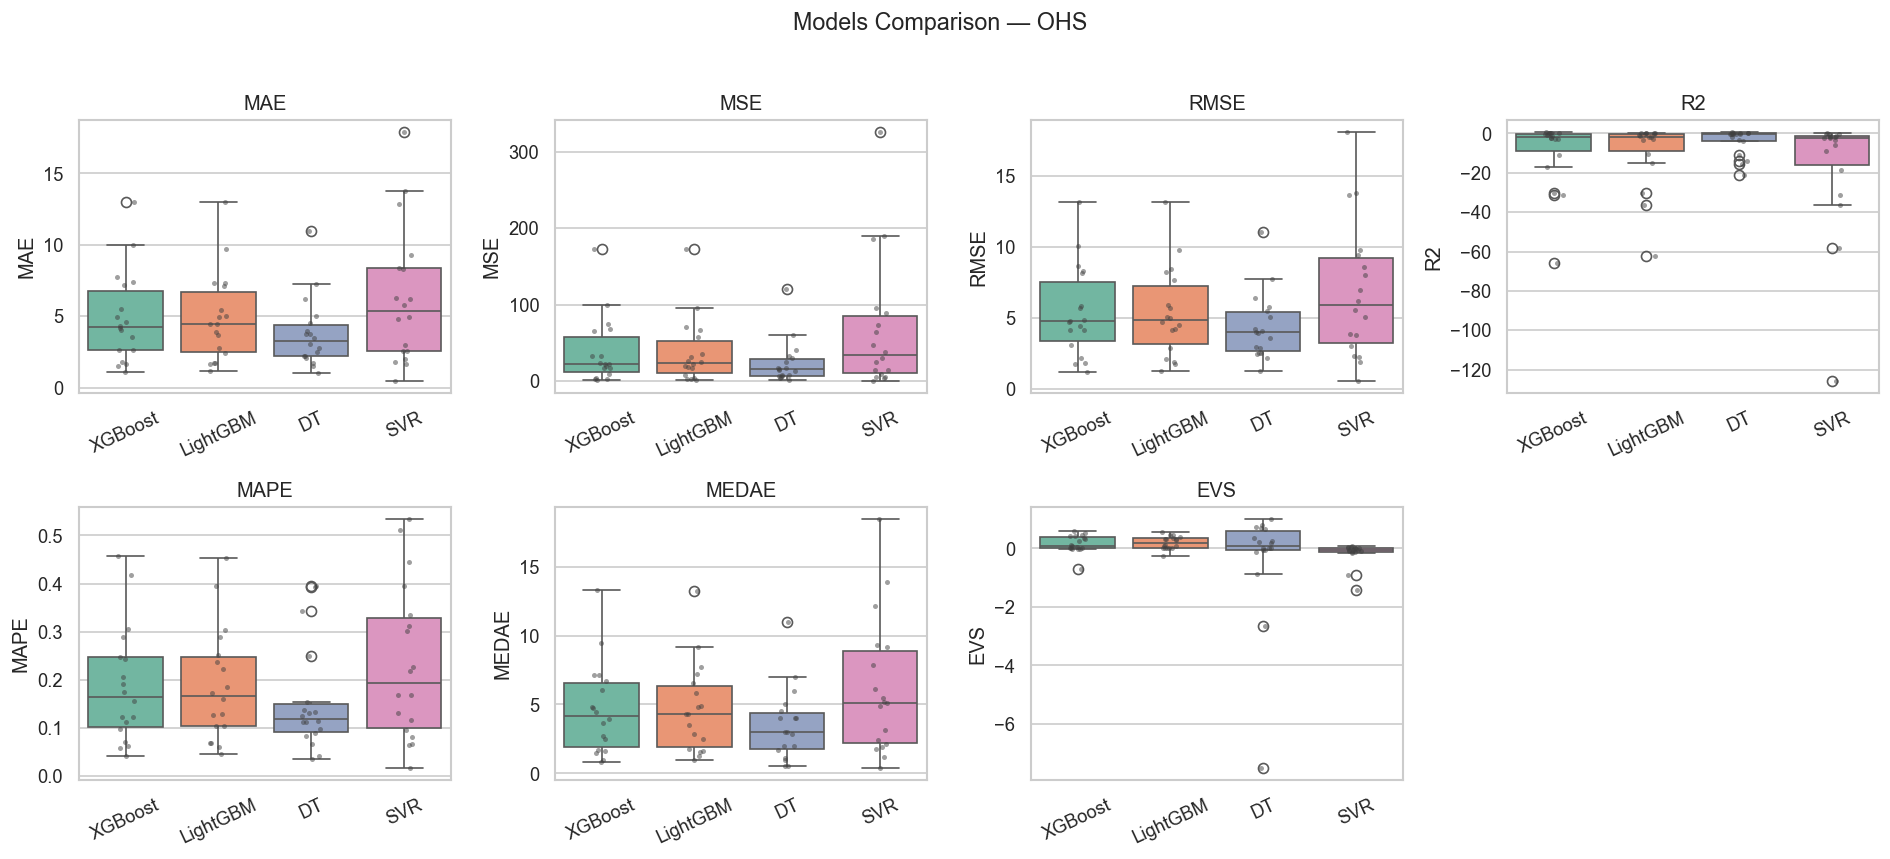

In [5]:
def plot_model_boxplots(df: pd.DataFrame, sheet_name: str, save: bool = True) -> None:
    plot_df = df.copy()
    plot_df["Model"] = plot_df["Model"].replace({"DecisionTreeRegressor (DT)": "DT"})
    plot_df["Model"] = pd.Categorical(plot_df["Model"], categories=["XGBoost", "LightGBM", "DT", "SVR"], ordered=True)
    plot_df = plot_df.sort_values("Model")

    n_metrics = len(METRICS)
    n_cols = 4
    n_rows = (n_metrics + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.5 * n_rows))
    axes = axes.flatten()

    for ax, metric in zip(axes, METRICS):
        sns.boxplot(
            data=plot_df,
            x="Model",
            y=metric,
            order=["XGBoost", "LightGBM", "DT", "SVR"],
            hue="Model",
            palette="Set2",
            legend=False,
            ax=ax,
        )
        sns.stripplot(
            data=plot_df,
            x="Model",
            y=metric,
            order=["XGBoost", "LightGBM", "DT", "SVR"],
            color="0.25",
            size=3,
            alpha=0.5,
            ax=ax,
        )
        ax.set_title(metric)
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=25)

    for ax in axes[n_metrics:]:
        ax.set_visible(False)

    fig.suptitle(f"Models Comparison — {sheet_name.upper()}", fontsize=14, y=1.02)
    fig.tight_layout()

    if save:
        out_path = FIGURES_DIR / f"boxplot_models_{sheet_name}.png"
        fig.savefig(out_path, bbox_inches="tight")
        print(f"Salvato: {out_path}")

    plt.show()


for sheet_name, df in sheets.items():
    plot_model_boxplots(df, sheet_name)

## Esportazione tabelle riassuntive (opzionale)

In [ ]:
summary_path = BASE_DIR / "results"  / "run_v5.3" / "summary_regression_stats.xlsx"
with pd.ExcelWriter(summary_path) as writer:
    for sheet_name, table in summary_tables.items():
        table.to_excel(writer, sheet_name=sheet_name)
print(f"Tabelle salvate in: {summary_path}")

Tabelle salvate in: C:\Users\Alessio\HOME\Git Projects (local)\MAISON-ML\results\run_v5.2\summary_regression_stats.xlsx
